# Fragility Score and portfolio evaluation

This notebook transforms the selected XGBoost predictions into within-quarter Fragility Scores, verifies their ranking of realized downside risk, and evaluates portfolios formed from that ranking. No model is retrained.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.evaluation.fragility import build_fragility_evaluation
from src.evaluation.investment import build_investment_evaluation
from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
modeling_tables = paths.tables / 'modeling'
evaluation_tables = paths.tables / 'evaluation'
set_matplotlib_style()

## Construct the Fragility Score

For each test quarter, the score is the percentile rank of predicted 63-day maximum drawdown. It ranges from 0 for the lowest predicted downside risk to 100 for the highest.

In [2]:
predictions = pd.read_parquet(
    modeling_tables / 'final_models_test_predictions.parquet'
).loc[lambda frame: frame['model'].eq('XGBoost')].copy()

ranks = predictions.groupby('report_period')[
    'predicted_future_max_drawdown_63d'
].rank(method='average')
quarter_sizes = predictions.groupby('report_period')[
    'predicted_future_max_drawdown_63d'
].transform('size')
predictions['fragility_score'] = (
    100 * (ranks - 1) / (quarter_sizes - 1)
).fillna(50)

selected_predictions = predictions[[
    'report_period', 'information_date', 'permno',
    'future_max_drawdown_63d',
    'predicted_future_max_drawdown_63d', 'fragility_score',
]].sort_values(['report_period', 'permno'])
selected_predictions_path = (
    modeling_tables / 'selected_model_test_predictions.parquet'
)
selected_predictions.to_parquet(
    selected_predictions_path, index=False, compression='zstd'
)

build_fragility_evaluation(
    predictions_path=selected_predictions_path,
    sample_path=paths.processed / 'modeling' / 'modeling_sample.parquet',
    daily_path=paths.raw / 'crsp' / 'daily_stock.parquet',
    output_directory=evaluation_tables,
    overwrite=True,
)
build_investment_evaluation(
    signals_path=evaluation_tables / 'fragility_stock_quarters.parquet',
    daily_stock_path=paths.raw / 'crsp' / 'daily_stock.parquet',
    market_index_path=paths.raw / 'crsp' / 'daily_market_index.parquet',
    factors_path=paths.interim / 'fama_french' / 'daily_factors.parquet',
    output_directory=evaluation_tables,
    overwrite=True,
)

InvestmentEvaluationResult(created=True, daily_returns_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/evaluation/fragility_strategy_daily_returns.parquet'), performance_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/evaluation/fragility_strategy_performance.csv'), alpha_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/evaluation/fragility_strategy_alpha.csv'), trading_days=502)

## Evaluate the score ranking

In [3]:
deciles = pd.read_csv(
    evaluation_tables / 'fragility_decile_quarterly.csv',
    parse_dates=['report_period', 'information_date'],
)
rank_correlations = pd.read_csv(
    evaluation_tables / 'fragility_rank_correlations.csv',
    parse_dates=['report_period', 'information_date'],
)
mean_deciles = deciles.groupby('fragility_decile', as_index=False).agg(
    mean_predicted_drawdown=('mean_predicted_drawdown', 'mean'),
    mean_realized_drawdown=('mean_realized_drawdown', 'mean'),
    mean_downside_volatility=('mean_downside_volatility', 'mean'),
    mean_worst_five_day_loss=('mean_worst_five_day_loss', 'mean'),
    mean_cumulative_return=('mean_cumulative_return', 'mean'),
)
score_summary = pd.DataFrame({
    'Statistic': [
        'Mean stock-level Spearman',
        'Mean decile-level Spearman',
        'Mean Decile 10 minus Decile 1 drawdown',
    ],
    'Value': [
        rank_correlations['stock_spearman'].mean(),
        rank_correlations['decile_spearman'].mean(),
        rank_correlations['top_minus_bottom_mean_drawdown'].mean(),
    ],
})
display(score_summary.style.format({'Value': '{:.3f}'}))
score_summary.to_latex(
    paths.tables / '04_09_fragility_score_summary.tex',
    index=False, float_format='%.3f',
    caption='Held-out Fragility Score ranking performance.',
    label='tab:fragility-score-summary',
)

,Statistic,Value
0,Mean stock-level Spearman,0.738
1,Mean decile-level Spearman,1.000
2,Mean Decile 10 minus Decile 1 drawdown,0.416


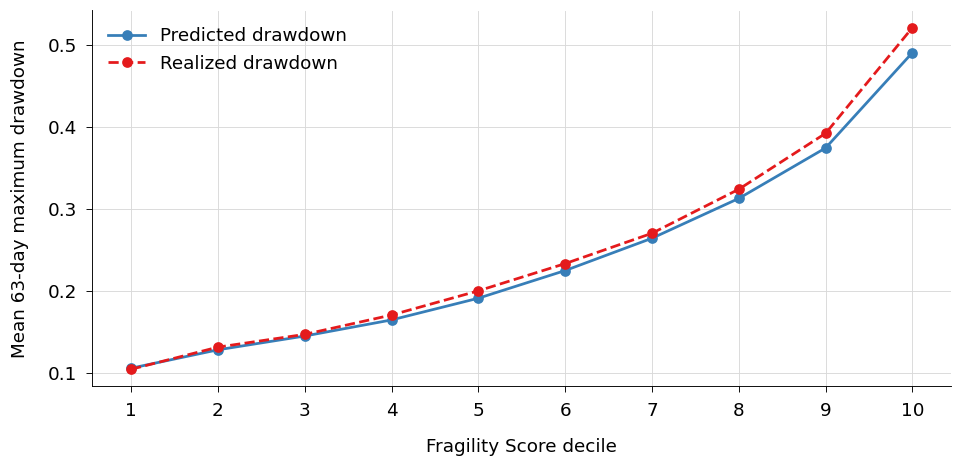

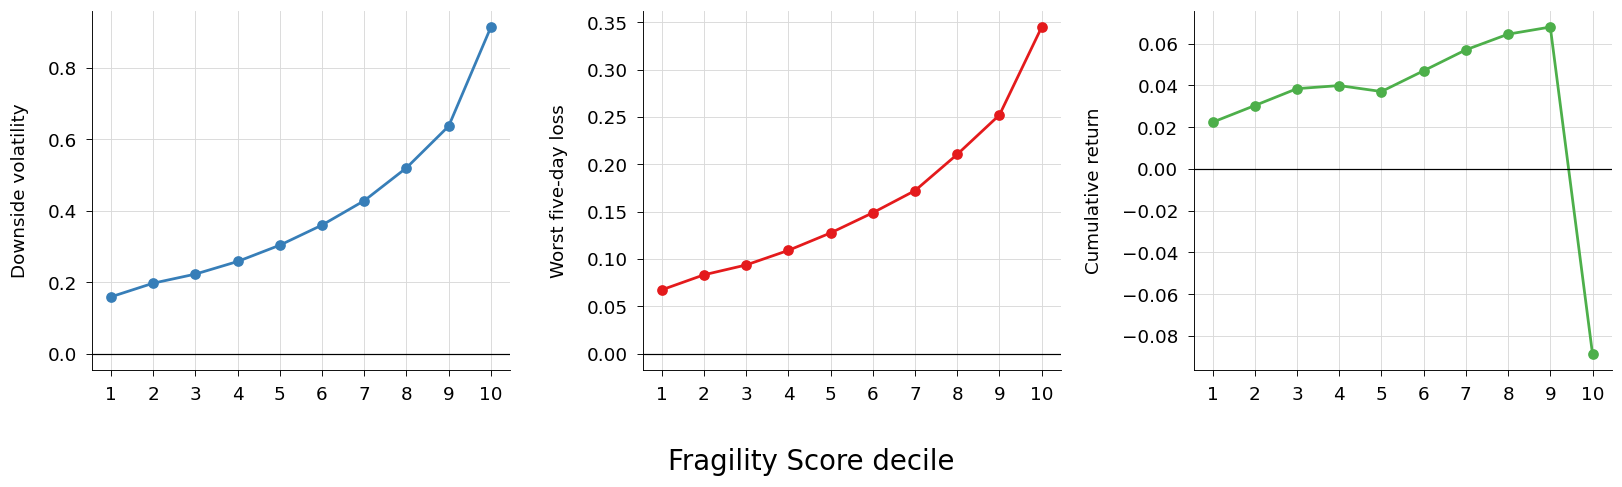

In [4]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    mean_deciles['fragility_decile'],
    mean_deciles['mean_predicted_drawdown'],
    marker='o', color=COLOR_PALETTE[0], label='Predicted drawdown',
)
axis.plot(
    mean_deciles['fragility_decile'],
    mean_deciles['mean_realized_drawdown'],
    marker='o', linestyle='--', color=COLOR_PALETTE[1],
    label='Realized drawdown',
)
axis.set_xlabel('Fragility Score decile')
axis.set_ylabel('Mean 63-day maximum drawdown')
axis.set_xticks(range(1, 11))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_fragility_score_deciles.pdf')
plt.show()

supporting_outcomes = [
    ('mean_downside_volatility', 'Downside volatility'),
    ('mean_worst_five_day_loss', 'Worst five-day loss'),
    ('mean_cumulative_return', 'Cumulative return'),
]
figure, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for index, (axis, (column, label)) in enumerate(
    zip(axes, supporting_outcomes)
):
    axis.plot(
        mean_deciles['fragility_decile'], mean_deciles[column],
        marker='o', color=COLOR_PALETTE[index],
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set_ylabel(label)
    axis.set_xticks(range(1, 11))
figure.supxlabel('Fragility Score decile')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_fragility_score_supporting_outcomes.pdf')
plt.show()

## Form and compare quarterly portfolios

At each information date, four equal-initial-weight portfolios are formed: all eligible stocks, the universe excluding Fragility Score Decile 10, Decile 1 alone, and Decile 10 alone. Constituents are held for 63 trading days without interim re-ranking.

In [5]:
portfolio_labels = {
    'all_stocks': 'Equal-weighted universe',
    'exclude_most_fragile_decile': 'Exclude Decile 10',
    'least_fragile_decile': 'Decile 1',
    'most_fragile_decile': 'Decile 10',
}
quarterly_portfolios = pd.read_csv(
    evaluation_tables / 'fragility_portfolio_quarterly.csv',
    parse_dates=['report_period', 'information_date', 'window_start', 'window_end'],
)
portfolio_summary = quarterly_portfolios.groupby('portfolio', as_index=False).agg(
    quarters=('report_period', 'nunique'),
    mean_maximum_drawdown=('maximum_drawdown', 'mean'),
    mean_downside_volatility=('downside_volatility', 'mean'),
    mean_worst_five_day_loss=('worst_five_day_loss', 'mean'),
    mean_cumulative_return=('cumulative_return', 'mean'),
)
portfolio_summary['portfolio'] = portfolio_summary['portfolio'].map(portfolio_labels)
display(portfolio_summary.style.format({
    'mean_maximum_drawdown': '{:.2%}',
    'mean_downside_volatility': '{:.2%}',
    'mean_worst_five_day_loss': '{:.2%}',
    'mean_cumulative_return': '{:.2%}',
}))
portfolio_summary.to_latex(
    paths.tables / '04_10_fragility_portfolio_event_windows.tex',
    index=False, float_format='%.4f',
    caption='Mean performance across quarterly 63-day portfolio windows.',
    label='tab:fragility-portfolio-event-windows',
)

,portfolio,quarters,mean_maximum_drawdown,mean_downside_volatility,mean_worst_five_day_loss,mean_cumulative_return
0,Equal-weighted universe,8,9.59%,13.55%,6.28%,3.16%
1,Exclude Decile 10,8,8.59%,12.67%,5.70%,4.50%
2,Decile 1,8,4.63%,6.86%,3.17%,2.24%
3,Decile 10,8,24.41%,27.14%,13.58%,-8.86%


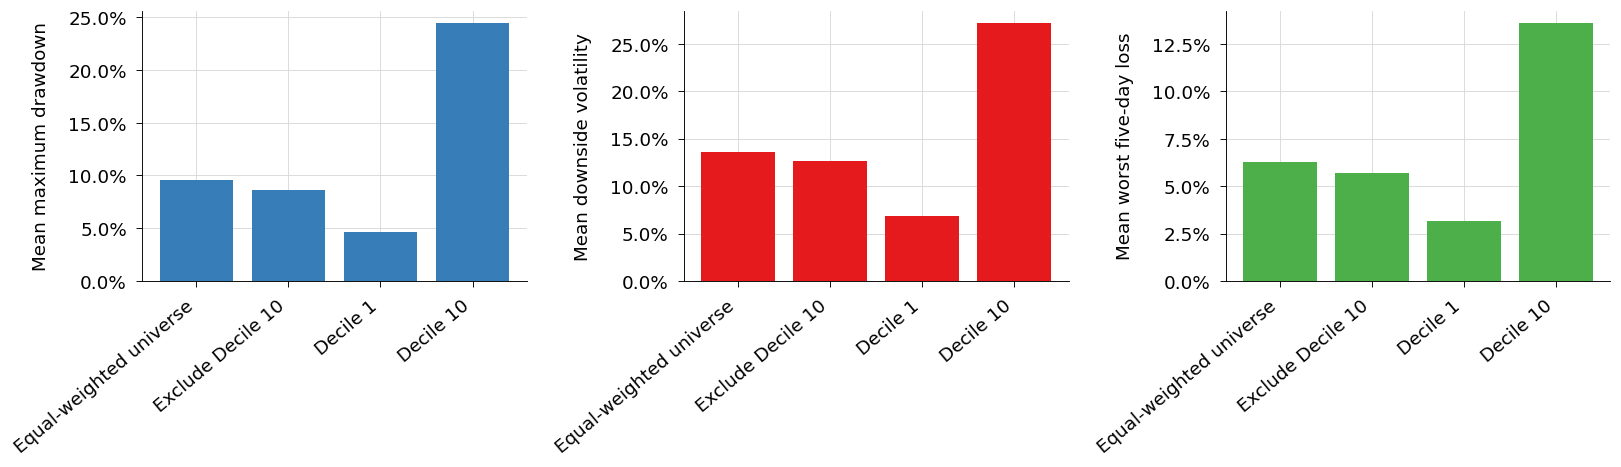

In [6]:
risk_measures = [
    ('mean_maximum_drawdown', 'Maximum drawdown'),
    ('mean_downside_volatility', 'Downside volatility'),
    ('mean_worst_five_day_loss', 'Worst five-day loss'),
]
positions = np.arange(len(portfolio_summary))
figure, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for index, (axis, (column, label)) in enumerate(zip(axes, risk_measures)):
    axis.bar(
        positions, portfolio_summary[column], color=COLOR_PALETTE[index],
    )
    axis.set_ylabel(f'Mean {label.lower()}')
    axis.set_xticks(positions)
    axis.set_xticklabels(
        portfolio_summary['portfolio'], rotation=40, ha='right',
    )
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_fragility_portfolio_risk.pdf')
plt.show()

## Continuous strategy and factor evaluation

In [7]:
strategy_labels = {
    'all_stocks': 'Equal-weighted universe',
    'exclude_most_fragile_decile': 'Exclude Decile 10',
    'crsp_total_market': 'CRSP total market',
}
strategy_performance = pd.read_csv(
    evaluation_tables / 'fragility_strategy_performance.csv'
)
strategy_performance['strategy'] = strategy_performance['strategy'].map(
    strategy_labels
)
display(strategy_performance.style.format({
    'cumulative_return': '{:.2%}', 'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.3f}',
    'maximum_drawdown': '{:.2%}', 'downside_volatility': '{:.2%}',
}))
strategy_performance.to_latex(
    paths.tables / '04_11_fragility_strategy_performance.tex',
    index=False, float_format='%.4f',
    caption='Continuous Fragility Score portfolio performance.',
    label='tab:fragility-strategy-performance',
)

,strategy,trading_days,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,Equal-weighted universe,502,16.17%,7.82%,20.37%,0.239,26.50%,14.14%
1,Exclude Decile 10,502,29.46%,13.84%,19.52%,0.519,24.11%,13.29%
2,CRSP total market,502,41.36%,18.98%,16.37%,0.854,19.11%,11.14%


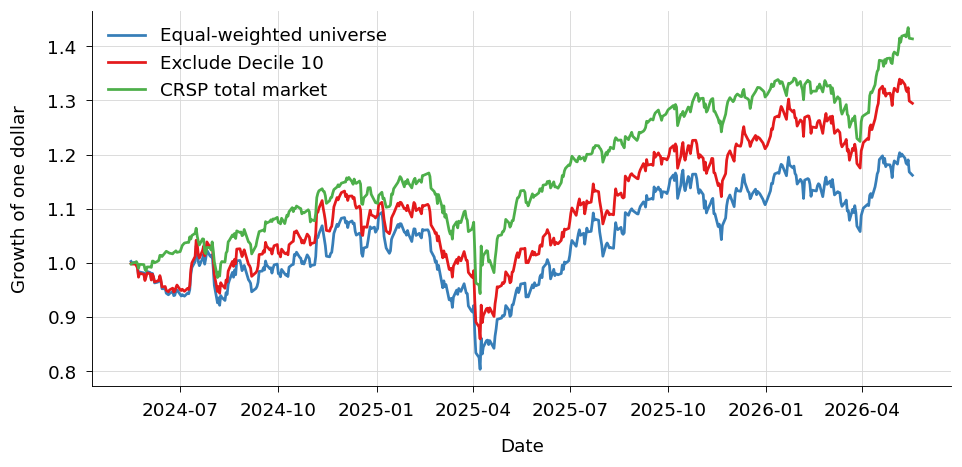

In [8]:
daily = pd.read_parquet(
    evaluation_tables / 'fragility_strategy_daily_returns.parquet'
)
wealth_columns = {
    'all_stocks_return': 'Equal-weighted universe',
    'screened_return': 'Exclude Decile 10',
    'crsp_market_return': 'CRSP total market',
}
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (column, label) in enumerate(wealth_columns.items()):
    wealth = (1 + daily[column]).cumprod()
    axis.plot(daily['date'], wealth, color=COLOR_PALETTE[index], label=label)
axis.set_xlabel('Date')
axis.set_ylabel('Growth of one dollar')
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_fragility_strategy_wealth.pdf')
plt.show()

,portfolio,annualized_alpha,alpha_standard_error,alpha_p_value,adjusted_r_squared
1,Equal-weighted universe,-5.20%,0.000153,0.179,0.946
3,Exclude Decile 10,0.02%,0.000098,0.992,0.974
5,Exclusion effect,5.22%,0.000075,0.006,0.174


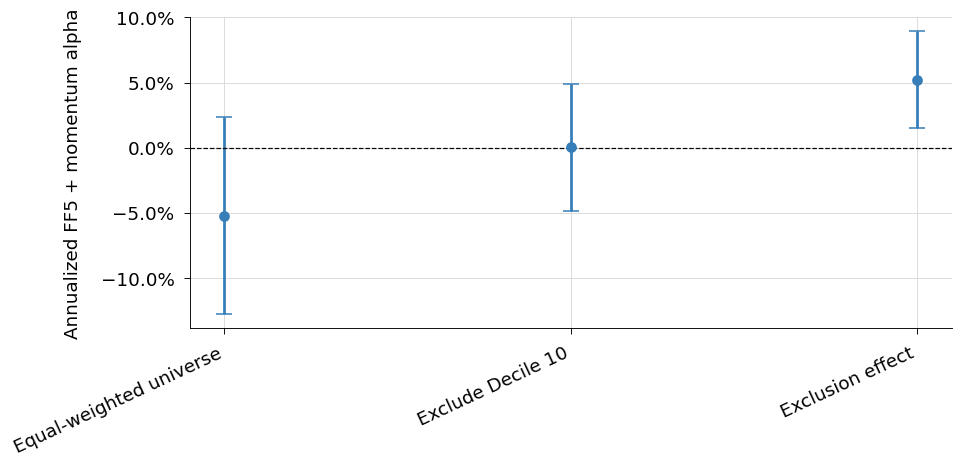

In [9]:
alpha = pd.read_csv(evaluation_tables / 'fragility_strategy_alpha.csv')
alpha_summary = alpha.loc[
    alpha['model'].eq('ff5_momentum'),
    ['portfolio', 'annualized_alpha', 'alpha_standard_error',
     'alpha_p_value', 'adjusted_r_squared'],
].copy()
alpha_summary['portfolio'] = alpha_summary['portfolio'].replace({
    **strategy_labels,
    'screened_minus_all_stocks': 'Exclusion effect',
})
display(alpha_summary.style.format({
    'annualized_alpha': '{:.2%}', 'alpha_p_value': '{:.3f}',
    'adjusted_r_squared': '{:.3f}',
}))

alpha_summary['ci95'] = 1.96 * 252 * alpha_summary['alpha_standard_error']
positions = np.arange(len(alpha_summary))
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.errorbar(
    positions, alpha_summary['annualized_alpha'],
    yerr=alpha_summary['ci95'], fmt='o', capsize=5,
    color=COLOR_PALETTE[0], ecolor=COLOR_PALETTE[0],
)
axis.axhline(0, color='black', linewidth=0.8, linestyle='--')
axis.set_ylabel('Annualized FF5 + momentum alpha')
axis.set_xticks(positions)
axis.set_xticklabels(alpha_summary['portfolio'], rotation=25, ha='right')
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_fragility_strategy_alpha.pdf')
plt.show()